In [ ]:
#------------------------  Libraries

In [ ]:
#download libraries if not already download
%pip install numpy
%pip install torch-directml
!python -m ipykernel install --user --name pydml --display-name "Python (PyTorch DirectML)"
%pip install matlabengine==25.1.2 

In [1]:
#Import Libraries
from tqdm.auto import tqdm
from scipy.io import loadmat
import numpy as np, math
import torch, torch_directml
import matlab.engine 
import os
import matplotlib.pyplot as plt

In [2]:
#------------------------ USER FILE 

In [3]:
matfile = r"Gun_Scan_20250830_181220.mat"  

In [4]:
#------------------------ Copy Matlab Variables into Python

In [5]:

matpath = os.path.abspath(matfile).replace("\\", "/")

# === Start MATLAB engine ===
eng = matlab.engine.start_matlab("-nojvm")

# === Load .mat into struct S ===
eng.eval(f"S = load('{matpath}');", nargout=0)

# === Push variables from struct S into MATLAB base workspace ===
eng.eval("""
recs           = S.recs;
xgrid          = S.xgrid;
ygrid          = S.ygrid;
zgrid          = S.zgrid;
freq           = S.freq;
TxRxPairs      = S.TxRxPairs;
printer_offsets = S.printer_offsets;
NxN            = S.NxN;
xstep          = S.xstep;
zstep          = S.zstep;
gridCenter     = S.gridCenter;
""", nargout=0)

#Load variables (consider building voxel grid in python after scanning)
recs            = np.array(eng.workspace["recs"])
xgrid           = np.array(eng.workspace["xgrid"]).reshape(-1).astype(np.float32)  # should be length 60 (or 1 if X is collapsed)
ygrid           = np.array(eng.workspace["ygrid"]).reshape(-1).astype(np.float32)  # expect 60
zgrid           = np.array(eng.workspace["zgrid"]).reshape(-1).astype(np.float32)  # expect 60
freq            = np.array(eng.workspace["freq"]).squeeze().astype(np.float32)  # -> shape (60,)
TxRxPairs       = np.array(eng.workspace["TxRxPairs"])
printer_offsets = np.array(eng.workspace["printer_offsets"])
NxN             = int(eng.workspace["NxN"])
xstep           = int(eng.workspace["xstep"])
zstep           = int(eng.workspace["zstep"])
gridCenter      = np.array(eng.workspace["gridCenter"])

print("Shapes:")
print("recs:", recs.shape)
print("xgrid:", xgrid.shape); print("ygrid:", ygrid.shape); print("zgrid:", zgrid.shape)
print("freq:", freq.shape)
print("xstep:", xstep, "zstep:", zstep)

#sanity for 1D Arrays
x1d = np.ravel(xgrid)
y1d = np.ravel(ygrid)
z1d = np.ravel(zgrid)


Shapes:
recs: (400, 100, 25)
xgrid: (101,)
ygrid: (101,)
zgrid: (31,)
freq: (100,)
xstep: 40 zstep: 40


In [6]:
#------------------------ Define Antenna Location constants

In [7]:
# === Antenna geometry (TX/RX element locations) ===
# Set UNIT_SCALE = 1.0 if values are already in meters (your case).
# Set UNIT_SCALE = 1e-3 if you paste millimeters instead.
import numpy as np
UNIT_SCALE = 1.0  # meters

# --- RX array: x=0, y increasing (20 elements) ---
RX_x = UNIT_SCALE * np.array([
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
], dtype=np.float32)

RX_y = UNIT_SCALE * np.array([
    0.0163, 0.0185, 0.0207, 0.0229, 0.0251, 0.0273, 0.0295, 0.0316,
    0.0338, 0.0360, 0.0382, 0.0404, 0.0426, 0.0447, 0.0469, 0.0491,
    0.0513, 0.0535, 0.0557, 0.0579
], dtype=np.float32)

# --- TX array: x decreasing, y ≈ 3 mm constant (20 elements) ---
TX_x = UNIT_SCALE * np.array([
    0.0533, 0.0512, 0.0491, 0.0470, 0.0449, 0.0428, 0.0407, 0.0386,
    0.0365, 0.0344, 0.0322, 0.0301, 0.0280, 0.0259, 0.0238, 0.0217,
    0.0196, 0.0175, 0.0154, 0.0133
], dtype=np.float32)

TX_y = UNIT_SCALE * np.array([
    0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030,
    0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030, 0.0030,
    0.0030, 0.0030, 0.0030, 0.0030
], dtype=np.float32)

Vant_x = np.concatenate((TX_x.ravel(), RX_x.ravel()))
Vant_y = np.concatenate((TX_y.ravel(),RX_y.ravel())); 
Vant_z = np.zeros_like(Vant_x)
Vant_xyz = np.stack((Vant_x, Vant_y, Vant_z))
Vant_xyz = np.transpose(Vant_xyz)
print(Vant_xyz.shape)
print(Vant_xyz)

# --- Quick sanity checks / convenience ---
assert TX_x.size == TX_y.size == RX_x.size == RX_y.size == 20, "Expected 20 elements each."

print("Shapes → TX_x:", TX_x.shape, "TX_y:", TX_y.shape, "RX_x:", RX_x.shape, "RX_y:", RX_y.shape)
print(TX_x); print(TX_y); print(RX_x); print(RX_y)

(40, 3)
[[0.0533 0.003  0.    ]
 [0.0512 0.003  0.    ]
 [0.0491 0.003  0.    ]
 [0.047  0.003  0.    ]
 [0.0449 0.003  0.    ]
 [0.0428 0.003  0.    ]
 [0.0407 0.003  0.    ]
 [0.0386 0.003  0.    ]
 [0.0365 0.003  0.    ]
 [0.0344 0.003  0.    ]
 [0.0322 0.003  0.    ]
 [0.0301 0.003  0.    ]
 [0.028  0.003  0.    ]
 [0.0259 0.003  0.    ]
 [0.0238 0.003  0.    ]
 [0.0217 0.003  0.    ]
 [0.0196 0.003  0.    ]
 [0.0175 0.003  0.    ]
 [0.0154 0.003  0.    ]
 [0.0133 0.003  0.    ]
 [0.     0.0163 0.    ]
 [0.     0.0185 0.    ]
 [0.     0.0207 0.    ]
 [0.     0.0229 0.    ]
 [0.     0.0251 0.    ]
 [0.     0.0273 0.    ]
 [0.     0.0295 0.    ]
 [0.     0.0316 0.    ]
 [0.     0.0338 0.    ]
 [0.     0.036  0.    ]
 [0.     0.0382 0.    ]
 [0.     0.0404 0.    ]
 [0.     0.0426 0.    ]
 [0.     0.0447 0.    ]
 [0.     0.0469 0.    ]
 [0.     0.0491 0.    ]
 [0.     0.0513 0.    ]
 [0.     0.0535 0.    ]
 [0.     0.0557 0.    ]
 [0.     0.0579 0.    ]]
Shapes → TX_x: (20,) TX_y: (20,

In [8]:
#------------------------ CPU system report

In [16]:
# CPU capability probe: specs + microbenches + safe budget
import os, time, gc, math, json, platform
import psutil
import torch

def _elem_size(dtype): return torch.tensor(0, dtype=dtype).element_size()

def _bench_elementwise(seconds=0.25, max_bytes=256_000_000, dtype=torch.float32, device=torch.device("cpu")):
    """Measure bytes/s for y = a*b + c (3 reads + 1 write)."""
    by = _elem_size(dtype)
    n  = max(1, (max_bytes // by) // 4)   # 4 arrays live
    a = torch.randn(n, dtype=dtype, device=device)
    b = torch.randn(n, dtype=dtype, device=device)
    c = torch.randn(n, dtype=dtype, device=device)
    for _ in range(2): _ = a*b + c
    it, t0 = 0, time.perf_counter()
    while time.perf_counter() - t0 < seconds:
        d = a*b + c
        it += 1
    dt = max(1e-9, time.perf_counter() - t0)
    elems = n*it
    bytes_moved = elems * by * 4
    return {"elems_per_s": elems/dt, "bytes_per_s": bytes_moved/dt, "n": n}

def _bench_memcpy(seconds=0.25, max_bytes=256_000_000, dtype=torch.float32, device=torch.device("cpu")):
    """Measure memcpy bandwidth via dst.copy_(src) (reads+writes = 2*)."""
    by = _elem_size(dtype)
    n  = max(1, max_bytes // by)
    src = torch.empty(n, dtype=dtype, device=device).normal_()
    dst = torch.empty_like(src)
    for _ in range(3): dst.copy_(src)
    it, t0 = 0, time.perf_counter()
    while time.perf_counter() - t0 < seconds:
        dst.copy_(src)
        it += 1
    dt = max(1e-9, time.perf_counter() - t0)
    bytes_moved = it * n * by * 2
    return {"bytes_per_s": bytes_moved/dt, "n": n}

def _bench_gemm(seconds=0.25, n0=512, dtype=torch.float32, device=torch.device("cpu")):
    """Rough GEMM GFLOPs using matmul (2*n^3 flops)."""
    n = n0
    A = torch.randn(n, n, dtype=dtype, device=device)
    B = torch.randn(n, n, dtype=dtype, device=device)
    C = A @ B  # warmup
    it, t0 = 0, time.perf_counter()
    while time.perf_counter() - t0 < seconds:
        C = A @ B
        it += 1
    dt = max(1e-9, time.perf_counter() - t0)
    flops = it * 2.0 * (n**3)
    return {"gflops": (flops/dt)/1e9, "n": n}

def _try_cpuinfo():
    try:
        import cpuinfo
        ci = cpuinfo.get_cpu_info()
        return {
            "brand_raw": ci.get("brand_raw"),
            "arch": ci.get("arch"),
            "bits": ci.get("bits"),
            "count_logical": psutil.cpu_count(logical=True),
            "count_physical": psutil.cpu_count(logical=False),
            "flags": ci.get("flags", []),
        }
    except Exception:
        return {
            "brand_raw": platform.processor() or platform.uname().processor,
            "arch": platform.machine(),
            "bits": 64 if platform.architecture()[0].startswith("64") else 32,
            "count_logical": psutil.cpu_count(logical=True),
            "count_physical": psutil.cpu_count(logical=False),
            "flags": [],
        }

def _try_caches_windows():
    # Best-effort cache sizes via WMI on Windows
    try:
        import wmi
        w = wmi.WMI()
        # Win32_Processor has L2CacheSize/L3CacheSize in KB (may be 0 on some systems)
        L2, L3 = None, None
        for p in w.Win32_Processor():
            L2 = (p.L2CacheSize or L2)
            L3 = (p.L3CacheSize or L3)
        # Win32_CacheMemory can give more detail, but we keep it simple
        return {
            "L2_bytes": int(L2)*1024 if L2 not in (None, 0) else None,
            "L3_bytes": int(L3)*1024 if L3 not in (None, 0) else None,
        }
    except Exception:
        return {"L2_bytes": None, "L3_bytes": None}

def probe_cpu(seconds=0.25, max_working_set=256_000_000, dtype=torch.float32, budget_fraction=0.5):
    """
    Returns a dict with CPU specs, SIMD flags, caches (best effort), memory,
    elementwise/ memcpy / gemm benches, and a conservative bytes budget for tiling.
    """
    specs = _try_cpuinfo()
    freq = psutil.cpu_freq()  # MHz; may be None on some systems
    vm = psutil.virtual_memory()

    # SIMD flags summary
    flags = set(specs.get("flags", []))
    simd = {
        "sse4_2": "sse4_2" in flags,
        "avx": "avx" in flags,
        "avx2": "avx2" in flags,
        "avx512f": "avx512f" in flags or "avx512" in flags,
        "fma": "fma" in flags or "fma3" in flags,
        "bf16": "avx512_bf16" in flags or "amx_bf16" in flags,
    }

    caches = _try_caches_windows() if os.name == "nt" else {"L2_bytes": None, "L3_bytes": None}

    # Microbenches
    elem = _bench_elementwise(seconds=seconds, max_bytes=max_working_set, dtype=dtype, device=torch.device("cpu"))
    memcpy = _bench_memcpy(seconds=seconds, max_bytes=max_working_set, dtype=dtype, device=torch.device("cpu"))
    gemm = _bench_gemm(seconds=seconds, n0=512, dtype=dtype, device=torch.device("cpu"))

    # Conservative memory budget for your tiler (leave headroom for OS and Jupyter)
    budget_bytes = int(vm.available * budget_fraction)

    return {
        "system": {
            "platform": f"{platform.system()} {platform.release()}",
            "python": platform.python_version(),
        },
        "cpu": {
            "model": specs.get("brand_raw"),
            "arch": specs.get("arch"),
            "bits": specs.get("bits"),
            "cores_physical": specs.get("count_physical"),
            "cores_logical": specs.get("count_logical"),
            "freq_mhz_current": getattr(freq, "current", None) if freq else None,
            "freq_mhz_min": getattr(freq, "min", None) if freq else None,
            "freq_mhz_max": getattr(freq, "max", None) if freq else None,
            "simd": simd,
            "caches": caches,
        },
        "memory": {
            "ram_total_Gbytes": vm.total / np.power(10,9),
            "ram_available_Gbytes": vm.available / np.power(10,9),
            "tile_budget_Gbytes": budget_bytes /  np.power(10,9),  # ← feed this to your chunk planner
        }

    }

# Pretty print
rep = probe_cpu()
print(json.dumps(rep, indent=2))


{
  "system": {
    "platform": "Windows 10",
    "python": "3.11.9"
  },
  "cpu": {
    "model": "AMD64 Family 25 Model 116 Stepping 1, AuthenticAMD",
    "arch": "AMD64",
    "bits": 64,
    "cores_physical": 8,
    "cores_logical": 16,
    "freq_mhz_current": 2470.0,
    "freq_mhz_min": 0.0,
    "freq_mhz_max": 4001.0,
    "simd": {
      "sse4_2": false,
      "avx": false,
      "avx2": false,
      "avx512f": false,
      "fma": false,
      "bf16": false
    },
    "caches": {
      "L2_bytes": null,
      "L3_bytes": null
    }
  },
  "memory": {
    "ram_total_Gbytes": 16.32618496,
    "ram_available_Gbytes": 3.06417664,
    "tile_budget_Gbytes": 1.53208832
  }
}


In [ ]:
#--------------------- DirectML GPU probe: adapters, VRAM, safe budget, microbench (fp16/fp32)

In [3]:
import gc, json, math, time, platform
from typing import Optional, Dict, Any

def probe_gpu_directml(budget_fraction: float = 0.55,
                       max_probe_elems: int = 64_000_000,
                       bench_bytes: int = 128_000_000,
                       bench_seconds: float = 0.25) -> Dict[str, Any]:
    """
    Returns a dict describing your DirectML environment and usable memory.
    - budget_fraction: fraction of probed contiguous bytes to treat as safe budget
    - max_probe_elems: cap for the binary-search allocation probe (float32 elements)
    - bench_bytes: working-set size for microbench
    - bench_seconds: duration per microbench
    """

    # --- imports & availability ---
    try:
        import torch
        HAS_TORCH = True
    except Exception:
        return {"directml_available": False, "error": "PyTorch not installed."}

    try:
        import torch_directml
        dml_device = torch_directml.device()
        DML_OK = True
    except Exception as e:
        return {"directml_available": False, "error": f"torch-directml not available: {e}"}

    # --- optional: ONNX Runtime DirectML presence ---
    ort_dml = False
    try:
        import onnxruntime as ort
        ort_dml = "DmlExecutionProvider" in ort.get_available_providers()
    except Exception:
        pass

    # --- adapter info via WMI (Windows only, best effort) ---
    adapters = []
    try:
        import wmi  # requires: pip install wmi
        w = wmi.WMI()
        for g in w.Win32_VideoController():
            # Some fields may be None depending on driver
            name = getattr(g, "Name", None)
            chip = getattr(g, "VideoProcessor", None)
            vram = getattr(g, "AdapterRAM", None)
            try:
                vram = int(vram) if vram is not None else None
            except Exception:
                vram = None
            adapters.append({"name": name, "chip": chip, "vram_bytes_total": vram})
    except Exception:
        # Non-Windows or WMI missing
        adapters = []

    # pick the adapter with max VRAM (informational only)
    chosen_adapter = None
    if adapters:
        idx = max(range(len(adapters)), key=lambda i: (adapters[i]["vram_bytes_total"] or 0))
        chosen_adapter = {**adapters[idx], "index": idx}

    # --- helper: element size ---
    def elem_size(dtype):
        return torch.tensor(0, dtype=dtype).element_size()

    # --- contiguous allocation probe (float32) ---
    def probe_contiguous_bytes(device, max_elems: int) -> int:
        by = elem_size(torch.float32)
        lo, hi, best = 1, max_elems, 0
        while lo <= hi:
            mid = (lo + hi) // 2
            try:
                _ = torch.empty(mid, dtype=torch.float32, device=device)
                best = mid
                del _
                gc.collect()
                lo = mid + 1
            except Exception:
                hi = mid - 1
                gc.collect()
        return best * by

    raw_contig_bytes = probe_contiguous_bytes(dml_device, max_probe_elems)
    budget_bytes = int(raw_contig_bytes * budget_fraction)

    # --- microbench (elementwise a*b + c) ---
    def bench_elementwise(device, dtype, seconds: float, max_bytes: int):
        by = elem_size(dtype)
        # 3 reads + 1 write live → ~4 arrays
        n = max(1, (max_bytes // by) // 4)
        a = torch.randn(n, device=device, dtype=dtype)
        b = torch.randn(n, device=device, dtype=dtype)
        c = torch.randn(n, device=device, dtype=dtype)
        # warmup
        for _ in range(2):
            _ = a * b + c
        t0 = time.perf_counter()
        it = 0
        while (time.perf_counter() - t0) < seconds:
            d = a * b + c
            it += 1
        # no explicit sync on DML; operations are eager
        dt = max(1e-9, time.perf_counter() - t0)
        elems = n * it
        bytes_moved = elems * by * 4
        return {"dtype": str(dtype).split(".")[-1], "elems_per_s": elems / dt, "bytes_per_s": bytes_moved / dt, "n": n}

    bench = {}
    # Try fp16; if unsupported on this path, record None
    try:
        bench["fp16"] = bench_elementwise(dml_device, torch.float16, bench_seconds, max(bench_bytes, budget_bytes // 2))
    except Exception as e:
        bench["fp16"] = {"error": f"{type(e).__name__}: {e}"}
    # Always do fp32
    try:
        bench["fp32"] = bench_elementwise(dml_device, torch.float32, bench_seconds, max(bench_bytes, budget_bytes // 2))
    except Exception as e:
        bench["fp32"] = {"error": f"{type(e).__name__}: {e}"}

    # --- package report ---
    report = {
        "system": {
            "platform": f"{platform.system()} {platform.release()}",
            "python": platform.python_version(),
        },
        "directml_available": DML_OK,
        "onnxruntime_dml_available": ort_dml,
        "device_str": "dml",
        "adapters": adapters,
        "chosen_adapter": chosen_adapter,
        "memory": {
            "raw_contiguous_Gbytes": raw_contig_bytes / np.power(10,9),
            "budget_fraction": budget_fraction,
            "budget_Gbytes": budget_bytes / np.power(10,9),
        },
        "microbench": bench,
    }
    return report

# Pretty print (example)
rep = probe_gpu_directml()
print(json.dumps(rep, indent=2))


{
  "system": {
    "platform": "Windows 10",
    "python": "3.11.9"
  },
  "directml_available": true,
  "onnxruntime_dml_available": false,
  "device_str": "dml",
  "adapters": [],
  "chosen_adapter": null,
  "memory": {
    "raw_contiguous_Gbytes": 0.256,
    "budget_fraction": 0.55,
    "budget_Gbytes": 0.1408
  },
  "microbench": {
    "fp16": {
      "dtype": "float16",
      "elems_per_s": 1271002287.793795,
      "bytes_per_s": 10168018302.35036,
      "n": 16000000
    },
    "fp32": {
      "dtype": "float32",
      "elems_per_s": 214655385.63383752,
      "bytes_per_s": 3434486170.1414003,
      "n": 8000000
    }
  }
}


In [ ]:
#------------------ Estimated computational complexity based on input file

In [22]:
import gc, platform, torch
torch.set_grad_enabled(False)

# Choose device (DirectML if present)
try:
    import torch_directml
    DEV = torch_directml.device()
    DEV_NAME = "dml"
except Exception:
    DEV = torch.device("cpu")
    DEV_NAME = "cpu"

def probe_vram_bytes(max_elems=64_000_000):
    """Binary-search the largest contiguous torch.float32 allocation on DEV."""
    elem_b = torch.tensor(0, dtype=torch.float32).element_size()
    lo, hi, best = 1, max_elems, 0
    while lo <= hi:
        mid = (lo + hi)//2
        try:
            _ = torch.empty(mid, dtype=torch.float32, device=DEV)
            best = mid
            del _
            gc.collect()
            lo = mid + 1
        except Exception:
            hi = mid - 1
            gc.collect()
    return best * elem_b  # bytes

TOTAL_BYTES = probe_vram_bytes()
BUDGET_BYTES = int(TOTAL_BYTES * 0.55)  # leave headroom (scheduler/driver)
print(dict(device=DEV_NAME, total_bytes=TOTAL_BYTES, budget_bytes=BUDGET_BYTES))

def estimate_greens2d_bytes(nTx, nRx, nF, nx, ny, dtype="single"):
    br = 4 if dtype=="single" else 8
    bc = br*2
    N  = int(nTx)*int(nRx)*int(nF)*int(nx)*int(ny)
    grids = 5*N*br
    rt_rr = 2*N*br
    G     = 1*N*bc / np.power(10,9)
    peak  = N*(9*br + bc)
    return {
        "N": N, "dtype": dtype,
        "grids_bytes": grids,
        "rt_rr_bytes": rt_rr,
        "G_Gibytes": G ,
        "peak_bytes_est": peak,
        "peak_GiB_est": peak/1024**3
    }
estimate_greens2d_bytes(TX_x.size, RX_x.size, freq.size, x1d.size, y1d.size, dtype="double")


{'device': 'dml', 'total_bytes': 256000000, 'budget_bytes': 140800000}


{'N': 408040000,
 'dtype': 'double',
 'grids_bytes': 16321600000,
 'rt_rr_bytes': 6528640000,
 'G_Gibytes': np.float64(6.52864),
 'peak_bytes_est': 35907520000,
 'peak_GiB_est': 33.44148397445679}

In [ ]:
#------------------------ Memory preallocation

In [ ]:
#------------------------ Backproject

In [9]:
import math, time, gc
import numpy as np
import torch
torch.set_grad_enabled(False)

# ---------- Complex helpers (RI channels) ----------
def _c_from_ri(r, i): return torch.stack([r, i], dim=-1)
def _c_mul(a, b):
    ar, ai = a[...,0], a[...,1]; br, bi = b[...,0], b[...,1]
    return _c_from_ri(ar*br - ai*br, ar*bi + ai*br)  # NOTE: br typo fixed → use bi in sums
def _c_mul(a, b):  # correct version
    ar, ai = a[...,0], a[...,1]; br, bi = b[...,0], b[...,1]
    return _c_from_ri(ar*br - ai*bi, ar*bi + ai*br)
def _cexp_posj(phi):  # conj(exp(-j*phi)) = exp(+j*phi)
    return _c_from_ri(torch.cos(phi), torch.sin(phi))
def _c_mag(ri): return torch.sqrt(ri[...,0]**2 + ri[...,1]**2)

# ---------- Progress bar ----------
try:
    from tqdm.auto import tqdm
    def _pbar(total, desc): return tqdm(total=total, desc=desc, leave=False)
except Exception:
    class _PB:
        def __init__(self, total, desc): self.t=0; self.T=total; print(desc)
        def update(self, n=1):
            self.t += n
            if self.t % max(1,self.T//20)==0 or self.t==self.T:
                print(f"  progress: {self.t}/{self.T}")
        def close(self): pass
    def _pbar(total, desc): return _PB(total, desc)

# ========================= MAIN =========================
def backproject2d_sum_scans(
    recordings,             # np.complex64/128, (nTx*nRx, nF, nRecs)
    TX_x, RX_y,             # np.float32, (nTx,), (nRx,)
    freq, xgrid, ygrid,     # np.float32, (nF,), (nx,), (ny,)
    printer_offsets,        # np.float32, (nRecs,2) [yoff, xoff]
    *,
    TX_y0=0.0,              # scalar, MATLAB TX_y(1,1)
    c=299_792_458.0,
    z_offset=0.5,
    device="cpu",           # "cpu" | "dml" | "cuda:0"
    f_chunk=8,              # frequency chunk length
    tile_xy=64,             # image tile size in x and y
    use_fp16=True,
    show_progress=True
):
    # --- device select ---
    if device == "dml":
        import torch_directml
        DEV = torch_directml.device()
    elif isinstance(device, str) and device.startswith("cuda"):
        DEV = torch.device(device)
    else:
        DEV = torch.device("cpu")

    # --- normalize inputs (NumPy) ---
    TX_x = np.asarray(TX_x, dtype=np.float32).reshape(-1)
    RX_y = np.asarray(RX_y, dtype=np.float32).reshape(-1)
    freq = np.asarray(freq,  dtype=np.float32).reshape(-1)
    xgrid = np.asarray(xgrid, dtype=np.float32).reshape(-1)
    ygrid = np.asarray(ygrid, dtype=np.float32).reshape(-1)
    recs  = np.asarray(recordings)

    nTx, nRx = TX_x.size, RX_y.size
    nF       = freq.size
    nx, ny   = xgrid.size, ygrid.size
    if recs.ndim != 3 or recs.shape[0] != nTx*nRx or recs.shape[1] != nF:
        raise ValueError(f"`recordings` shape {recs.shape} must be (nTx*nRx, nF, nRecs)")
    nRecs = recs.shape[2]

    printer_offsets = np.asarray(printer_offsets, dtype=np.float32)
    if printer_offsets.shape != (nRecs, 2):
        raise ValueError(f"`printer_offsets` shape {printer_offsets.shape} must be (nRecs, 2) [yoff, xoff]")

    # --- complex → RI on CPU: (nTx,nRx,nF,nRecs,2) ---
    if np.iscomplexobj(recs):
        recs = np.stack([recs.real, recs.imag], axis=-1).astype(np.float32)
    else:
        recs = np.stack([recs.astype(np.float32),
                         np.zeros_like(recs, dtype=np.float32)], axis=-1)
    recs = recs.reshape(nTx, nRx, nF, nRecs, 2)
    recs_cpu = torch.from_numpy(recs)  # CPU tensor

    # --- constants / vectors ---
    comp_dtype = torch.float16 if (use_fp16 and DEV.type != "cpu") else torch.float32
    two_pi_over_c = 2.0 * math.pi / c

    F_all_t = torch.from_numpy(freq).to(DEV, dtype=comp_dtype)  # (nF,)
    X_cpu   = torch.from_numpy(xgrid)                           # CPU
    Y_cpu   = torch.from_numpy(ygrid)                           # CPU

    # per-scan TX/RX offsets (MATLAB BP_TX_x/BP_RX_y)
    xoff = printer_offsets[:, 1]                                # x offset
    yoff = printer_offsets[:, 0]                                # y offset
    TX_off = (TX_x[None, :] - xoff[:, None]).astype(np.float32) # (nRecs,nTx)
    RX_off = (RX_y[None, :] - yoff[:, None]).astype(np.float32) # (nRecs,nRx)

    TX_y0_t = torch.tensor(float(TX_y0), dtype=comp_dtype, device=DEV)
    z0_t    = torch.tensor(float(z_offset), dtype=comp_dtype, device=DEV)

    # --- output accumulator (on device, fp32) ---
    Im = torch.zeros(nx, ny, 2, device=DEV, dtype=torch.float32)

    # --- timing + progress ---
    n_xtiles = (nx + tile_xy - 1) // tile_xy
    n_ytiles = (ny + tile_xy - 1) // tile_xy
    total_steps = nRecs * n_xtiles * n_ytiles
    t0 = time.perf_counter()
    pbar = _pbar(total_steps, "Backproject 2D (all scans)") if show_progress else None

    # ===================== loops =====================
    try:
        for i in range(nRecs):
            TXi = torch.from_numpy(TX_off[i]).to(DEV, dtype=comp_dtype)  # (nTx,)
            RXi = torch.from_numpy(RX_off[i]).to(DEV, dtype=comp_dtype)  # (nRx,)

            for x0 in range(0, nx, tile_xy):
                x1 = min(x0 + tile_xy, nx)
                nx_tile = x1 - x0
                if nx_tile <= 0:
                    if pbar: pbar.update(1)
                    continue

                # define Xtile here
                Xtile = X_cpu[x0:x1].to(DEV, dtype=comp_dtype).view(-1, 1)  # (nx_tile,1)

                for y0 in range(0, ny, tile_xy):
                    y1 = min(y0 + tile_xy, ny)
                    ny_tile = y1 - y0
                    if ny_tile <= 0:
                        if pbar: pbar.update(1)
                        continue

                    # define Ytile here
                    Ytile = Y_cpu[y0:y1].to(DEV, dtype=comp_dtype).view(1, -1)  # (1,ny_tile)

                    tile_acc = torch.zeros(nx_tile, ny_tile, 2, device=DEV, dtype=comp_dtype)

                    # TX/RX loops use scalar xt/yr (device tensors)
                    for itx in range(nTx):
                        xt = TXi[itx]
                        Rt_tx = torch.sqrt((xt - Xtile)**2 + (TX_y0_t - Ytile)**2 + (0.0 - z0_t)**2)

                        for irx in range(nRx):
                            yr = RXi[irx]
                            Rr_rx = torch.sqrt((0.0 - Xtile)**2 + (yr - Ytile)**2 + (0.0 - z0_t)**2)
                            rsum  = Rt_tx + Rr_rx

                            # frequency chunks
                            for f0 in range(0, nF, f_chunk):
                                f1 = min(f0 + f_chunk, nF)
                                if f1 <= f0:  # guard
                                    continue

                                Fseg = F_all_t[f0:f1].view(1, 1, -1)                     # (1,1,fC)
                                phi  = (two_pi_over_c * Fseg) * rsum.unsqueeze(-1)       # (tx,ty,fC)
                                G_conj = _cexp_posj(phi)                                  # (tx,ty,fC,2)

                                s_cpu = recs_cpu[itx, irx, f0:f1, i, :]                  # (fC,2) CPU
                                s     = s_cpu.to(DEV, dtype=comp_dtype).view(1,1,-1,2)   # (1,1,fC,2)

                                tile_acc = tile_acc + _c_mul(G_conj, s).sum(dim=2)       # (tx,ty,2)

                            del Rr_rx, rsum
                        del Rt_tx

                    Im[x0:x1, y0:y1] += tile_acc.to(torch.float32)
                    del tile_acc, Ytile
                    gc.collect()
                    if pbar: pbar.update(1)

                del Xtile
                gc.collect()

            del TXi, RXi
            gc.collect()
    finally:
        if pbar: pbar.close()

    dt = time.perf_counter() - t0
    print(f"[backproject] scans={nRecs} tiles={n_xtiles}x{n_ytiles} "
          f"elapsed={dt:.2f}s  avg/scan={dt/max(1,nRecs):.3f}s")

    return Im  # (nx,ny,2) on device

# ---- turn RI image into dB on CPU ----
def image_db_from_ri(Im_ri):
    Im_mag = _c_mag(Im_ri).to("cpu")
    Im_mag = Im_mag / Im_mag.max().clamp(min=1e-12)
    return 20.0 * torch.log10(Im_mag.clamp(min=1e-12))  # (nx,ny)



In [10]:
Im_ri = backproject2d_sum_scans(
    recordings      = recs,             # (nTx*nRx, nF, nRecs) complex
    TX_x            = TX_x,             # (nTx,)
    RX_y            = RX_y,             # (nRx,)
    freq            = freq,             # (nF,)
    xgrid           = xgrid,            # (nx,)
    ygrid           = ygrid,            # (ny,)
    printer_offsets = printer_offsets,  # (nRecs,2) [yoff, xoff]
    TX_y0           = float(TX_y[0]),
    device          = "dml",            # or "cpu"/"cuda:0"
    f_chunk         = 8,
    tile_xy         = 64,
    use_fp16        = True,
    show_progress   = True
)

Im_db = image_db_from_ri(Im_ri)


Backproject 2D (all scans):   0%|          | 0/100 [00:00<?, ?it/s]

[backproject] scans=25 tiles=2x2 elapsed=565.80s  avg/scan=22.632s


In [ ]:
#------------------------ 2D Plotting

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

# ---------- helpers ----------

def _as_numpy(a, expect_complex=False):
    """Return a as a NumPy array. Handles torch tensors on cuda/dml/mps/cpu.
       If expect_complex and input is two-channel (...,2) real, convert to complex."""
    try:
        import torch
        if isinstance(a, torch.Tensor):
            t = a.detach().cpu()
            if t.is_complex():
                return t.numpy()
            if expect_complex and t.ndim >= 1 and t.shape[-1] == 2:
                # interpret last dim as [real, imag]
                return t[..., 0].numpy() + 1j * t[..., 1].numpy()
            return t.numpy()
    except Exception:
        pass
    a_np = np.asarray(a)
    if expect_complex and (a_np.ndim >= 1 and a_np.shape[-1] == 2) and np.isrealobj(a_np):
        a_np = a_np[..., 0] + 1j * a_np[..., 1]
    return a_np

def _to_db(mag, ref=None, eps=1e-12):
    mag = np.asarray(mag)
    if ref is None:
        ref = np.max(mag) if mag.size else 1.0
    ref = max(float(ref), eps)
    return 20.0 * np.log10(np.maximum(mag, eps) / ref)

def _normalize_shapes(Im_ri, xgrid, ygrid):
    """Accepts Im_ri shaped (nx,ny,nScans), (ny,nx,nScans), (nScans,nx,ny), (nScans,ny,nx), (nx,ny), (ny,nx).
       Returns scans: (nScans, ny, nx) or None; summed: (ny, nx); nScans."""
    nx, ny = len(xgrid), len(ygrid)
    A = np.asarray(Im_ri)

    if A.ndim == 2:
        if A.shape == (nx, ny):     # (x,y)
            summed = A.T            # -> (y,x)
        elif A.shape == (ny, nx):   # (y,x)
            summed = A
        else:
            raise ValueError(f"Im_ri 2D shape {A.shape} != (nx,ny) or (ny,nx) with nx={nx}, ny={ny}.")
        return None, summed, 0

    if A.ndim != 3:
        raise ValueError("Im_ri must be 2D or 3D.")

    if A.shape[0] == nx and A.shape[1] == ny:        # (nx,ny,nScans)
        scans = np.transpose(A, (2, 1, 0))           # -> (nScans, y, x)
    elif A.shape[0] == ny and A.shape[1] == nx:      # (ny,nx,nScans)
        scans = np.transpose(A, (2, 0, 1))           # -> (nScans, y, x)
    elif A.shape[1] == nx and A.shape[2] == ny:      # (nScans,nx,ny)
        scans = np.transpose(A, (0, 2, 1))           # -> (nScans, y, x)
    elif A.shape[1] == ny and A.shape[2] == nx:      # (nScans,ny,nx)
        scans = A                                    # -> (nScans, y, x)
    else:
        raise ValueError(f"Im_ri 3D shape {A.shape} incompatible with nx={nx}, ny={ny}.")

    summed = np.sum(scans, axis=0)  # coherent sum (complex)
    return scans, summed, scans.shape[0]

# ---------- main API (plot-only) ----------

def plot_scans_and_sum(
    Im_ri,
    xgrid,                 # x: vertical height samples (m)
    ygrid,                 # y: horizontal movement samples (m)
    *,
    plane="xy",            # "xy" (fixed z) or "yz" (fixed x)
    plane_coord_m=None,    # z for XY; x for YZ  (required)
    vmin_db=-35, vmax_db=0,
    show_sum_phase=False,
    max_scans_to_show=25,
    title_prefix=None
):
    """
    Plot up to 25 per-scan images PLUS the coherent sum, without calling BP.

    Conventions:
      - z = down-range (constant for XY)
      - x = vertical height (constant for YZ)
      - y = horizontal movement

    Inputs can be NumPy arrays or torch tensors on any device.
    """
    # Convert all inputs to NumPy on CPU (safe for matplotlib & numpy ops)
    Im_ri = _as_numpy(Im_ri, expect_complex=True)
    xgrid = _as_numpy(xgrid)
    ygrid = _as_numpy(ygrid)

    if not np.iscomplexobj(Im_ri):
        raise TypeError("Im_ri must be complex (phase-preserving). If you stored [real,imag], pass them as last-dim size 2.")

    scans, summed, nScans = _normalize_shapes(Im_ri, xgrid, ygrid)  # -> (nScans, y, x) and (y, x)

    if plane.lower() == "xy":
        if plane_coord_m is None:
            raise ValueError("For plane='xy', set plane_coord_m = z (meters).")
        # Axes: horizontal=y, vertical=x
        xlabel, ylabel = "y (m)", "x (m)"
        extent = [float(np.min(ygrid)), float(np.max(ygrid)),
                  float(np.min(xgrid)), float(np.max(xgrid))]
        subtitle = f" @ z = {plane_coord_m:.4f} m"

        def orient(arr_yx):  # (y,x) -> (x,y) for imshow (rows,cols)
            return arr_yx.T

    elif plane.lower() == "yz":
        if plane_coord_m is None:
            raise ValueError("For plane='yz', set plane_coord_m = x (meters).")
        # For YZ, caller should have used xgrid = zgrid for the reconstruction.
        xlabel, ylabel = "y (m)", "z (m)"
        zmin, zmax = float(np.min(xgrid)), float(np.max(xgrid))  # here xgrid carries z sampling
        extent = [float(np.min(ygrid)), float(np.max(ygrid)), zmin, zmax]
        subtitle = f" @ x = {plane_coord_m:.4f} m"

        def orient(arr_yz):  # (y,z) -> (z,y)
            return arr_yz.T

    else:
        raise ValueError("plane must be 'xy' or 'yz'.")

    ref = np.max(np.abs(summed)) if summed.size else 1.0

    # ---- Per-scan panels ----
    fig = None
    if scans is not None and nScans > 0:
        n_show = min(nScans, max_scans_to_show)
        ncols = 5
        nrows = ceil(n_show / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 3.2*nrows), constrained_layout=True)
        axes = np.atleast_2d(axes)
        last_im = None

        for i in range(nrows * ncols):
            ax = axes.flat[i]
            if i < n_show:
                scan_db = _to_db(np.abs(scans[i]), ref=ref)
                img = orient(scan_db)
                last_im = ax.imshow(img, origin="lower", extent=extent, aspect="auto",
                                    vmin=vmin_db, vmax=vmax_db)
                ax.set_title(f"{(title_prefix + ' – ') if title_prefix else ''}Scan {i+1}{subtitle}", fontsize=9)
                if i % ncols == 0: ax.set_ylabel(ylabel)
                if i // ncols == nrows - 1: ax.set_xlabel(xlabel)
            else:
                ax.axis("off")

        if last_im is not None:
            cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.9, pad=0.01)
            cbar.set_label("|I| (dB rel. sum peak)")

    # ---- Coherent sum ----
    fig_sum, ax_sum = plt.subplots(figsize=(6, 5), constrained_layout=True)
    sum_db = _to_db(np.abs(summed), ref=ref)
    ims = ax_sum.imshow(orient(sum_db), origin="lower", extent=extent, aspect="auto",
                        vmin=vmin_db, vmax=vmax_db)
    ax_sum.set_title(f"{(title_prefix + ' – ') if title_prefix else ''}Coherent Sum (|I| dB){subtitle}", fontsize=11)
    ax_sum.set_xlabel(xlabel); ax_sum.set_ylabel(ylabel)
    cbar2 = fig_sum.colorbar(ims, ax=ax_sum); cbar2.set_label("|I| (dB rel. sum peak)")

    # Optional phase of the coherent sum (useful to verify coherence)
    fig_phase = None
    if show_sum_phase:
        fig_phase, axp = plt.subplots(figsize=(6, 5), constrained_layout=True)
        phase = np.angle(summed)
        imp = axp.imshow(orient(phase), origin="lower", extent=extent, aspect="auto")
        axp.set_title(f"{(title_prefix + ' – ') if title_prefix else ''}Coherent Sum – Phase (rad){subtitle}")
        axp.set_xlabel(xlabel); axp.set_ylabel(ylabel)
        plt.colorbar(imp, ax=axp, label="phase (rad)")

    return fig, fig_sum, fig_phase


In [ ]:
#------------------------ 2D Plotting Calls

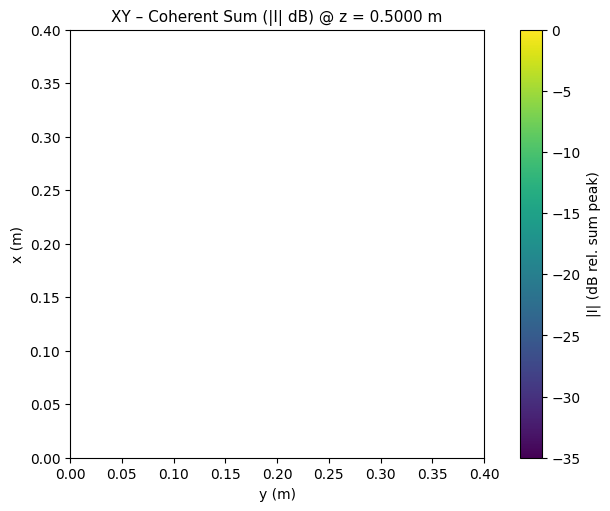

In [18]:
# Im_ri_xy can be torch (on dml/cuda/cpu) or numpy; shape either (nx,ny,25) stack or (nx,ny)/(ny,nx) sum
figs = plot_scans_and_sum(
    Im_ri=Im_ri,
    xgrid=xgrid,     # x = vertical height
    ygrid=ygrid,     # y = horizontal
    plane="xy",
    plane_coord_m=0.50,   # your Green’s-plane z (meters)
    vmin_db=-35, vmax_db=0,
    title_prefix="XY",
    show_sum_phase=False
)


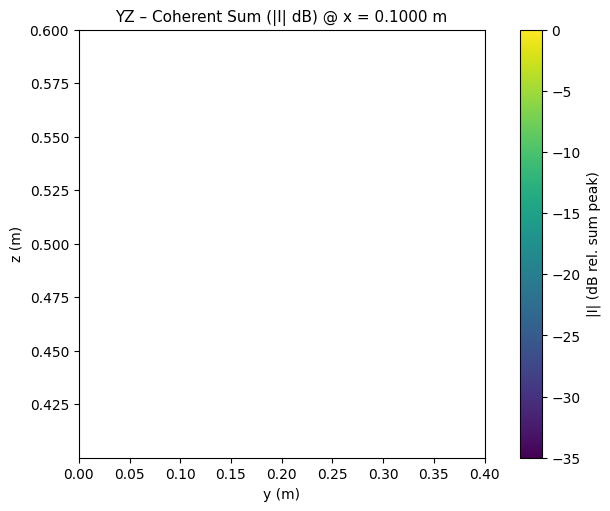

In [20]:
# For YZ, reconstruct with xgrid=zgrid (down-range), ygrid=ygrid (horizontal)
figs = plot_scans_and_sum(
    Im_ri=Im_ri_yz,
    xgrid=zgrid,     # z = down-range
    ygrid=ygrid,     # y = horizontal
    plane="yz",
    plane_coord_m=0.10,   # x (vertical height) of the slice in meters
    vmin_db=-35, vmax_db=0,
    title_prefix="YZ",
    show_sum_phase=False
)


In [ ]:
#------------------------ 3D Plotting

In [21]:
print(Im_ri.shape)
print(Im_ri.max)
print(Im_ri.min)

torch.Size([101, 101, 2])
<built-in method max of Tensor object at 0x0000029716238350>
<built-in method min of Tensor object at 0x0000029716238350>
